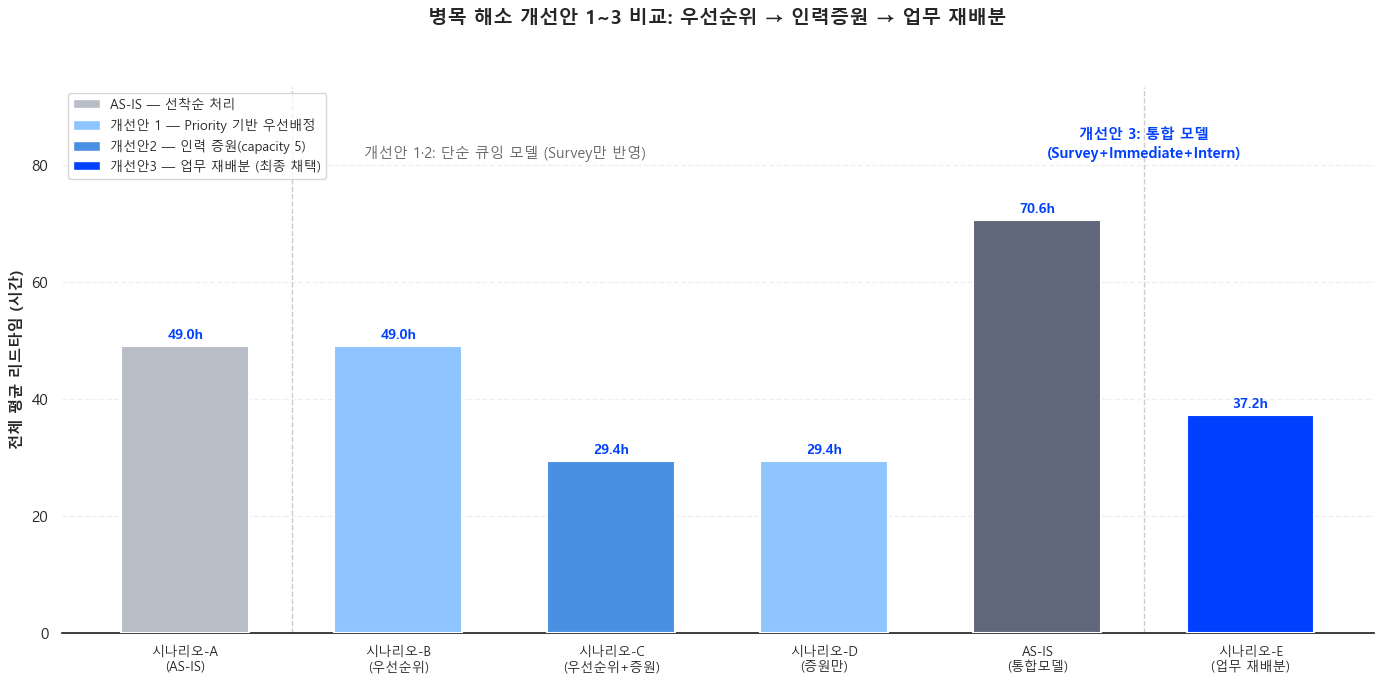

In [527]:
from matplotlib.patches import Patch, Rectangle

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 데이터 준비
# ============================================================
labels_all = [
    "시나리오-A\n(AS-IS)",
    "시나리오-B\n(우선순위)",
    "시나리오-C\n(우선순위+증원)",
    "시나리오-D\n(증원만)",
    "AS-IS\n(통합모델)",
    "시나리오-E\n(업무 재배분)",
]

lead_times = [
    scenario_A["lead_time_hr"],
    scenario_B["lead_time_hr"],
    scenario_C["lead_time_hr"],
    scenario_D["lead_time_hr"],
    as_is_integrated["lead_time_hr"].mean(), 
    scenario_E_result["lead_time_hr"].mean(), 
]

# 그룹 구분용 색상 (시도1/2 = 회색조, 시도3 = 강조색)
group_colors = [
    "#B8BDC7",   # A — AS-IS
    "#8EC5FF",   # B — Priority
    "#4A90E2",   # C — Priority + Capacity
    "#8EC5FF",   # D — Capacity Only

    "#61677A",   # 통합 AS-IS
    "#0040FF",   # E — 업무 재배분
]

fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")

x = np.arange(len(labels_all))
bars = ax.bar(x, lead_times, color=group_colors, width=0.6, zorder=3, edgecolor="white", linewidth=1.5)

# 값 라벨
for i, (bar, val) in enumerate(zip(bars, lead_times)):
    # 최종 개선안 E만 강조
    text_color = "#0040FF" if i == 5 else "#333333"
    
    ax.annotate(f"{val:.1f}h", xy=(bar.get_x()+bar.get_width()/2, val),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                color="#0040FF")

# 시도1/2/3 구간 구분선 및 라벨
ax.axvline(0.5, color="#CCCCCC", linestyle="--", linewidth=1, zorder=1)
ax.axvline(4.5, color="#CCCCCC", linestyle="--", linewidth=1, zorder=1)

y_top = max(lead_times) * 1.15
ax.text(1.5, y_top, "개선안 1·2: 단순 큐잉 모델 (Survey만 반영)", ha="center", fontsize=10.5, color="#666666", style="italic")
ax.text(4.5, y_top, "개선안 3: 통합 모델\n(Survey+Immediate+Intern)", ha="center", fontsize=10.5, color="#0040FF", style="italic", fontweight="bold")

ax.set_title("병목 해소 개선안 1~3 비교: 우선순위 → 인력증원 → 업무 재배분", fontsize=14, fontweight="bold", pad=45)
ax.set_ylabel("전체 평균 리드타임 (시간)", fontsize=11, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels_all, fontsize=9.5)

ax.set_ylim(0, y_top * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

legend_handles = [
    Patch(facecolor="#B8BDC7", label="AS-IS — 선착순 처리"),
    Patch(facecolor="#8EC5FF", label="개선안 1 — Priority 기반 우선배정"),
    Patch(facecolor="#4A90E2", label="개선안2 — 인력 증원(capacity 5)"),
    Patch(facecolor="#0040FF", label="개선안3 — 업무 재배분 (최종 채택)"),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=9.5)

#plt.figtext(0.5, -0.02,
#    "※ AS-IS(단순모델)/개선안1·2는 Survey 단독 큐잉 모델, AS-IS(통합모델)/개선안3은 Survey+ImmediateRepair+InternRepair를\n"
#    "함께 반영한 통합 모델 기준으로, 서로 다른 모델에서 산출된 값입니다. 절대값 비교보다 각 그룹 내 상대적 개선폭에 주목하세요.",
#    ha="center", fontsize=8.5, color="#888888")

plt.tight_layout()
plt.savefig("scenario_1_2_3_comparison.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

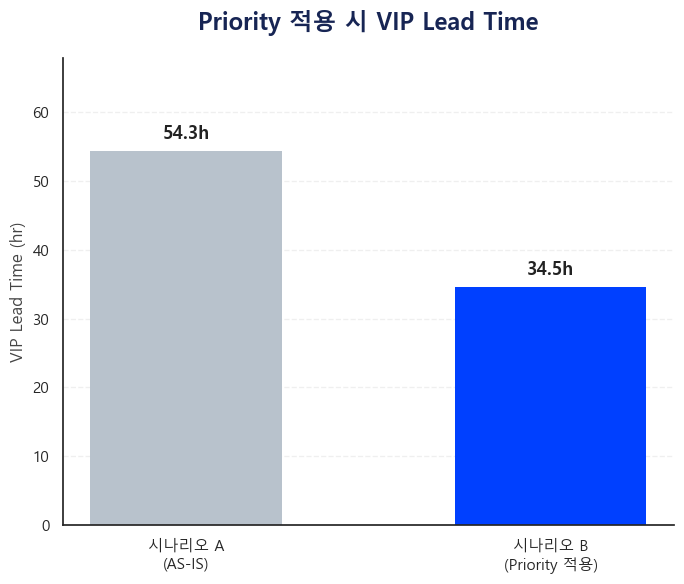

In [528]:
# 시나리오 A | VIP Lead Time 비교
# AS-IS vs Priority 적용 vs Priority + VIP 우선

scenario_order = ["시나리오 A (AS-IS)", "시나리오 B"]

plot_df = final_results[final_results["Scenario"].isin(scenario_order)].copy()

# 원하는 순서로 정렬
plot_df["Scenario"] = pd.Categorical(plot_df["Scenario"], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values("Scenario")

# 값
values = plot_df["VIP Lead Time (hr)"].values


colors = [
    "#B8C2CC",   # 시나리오 A : 차분한 회색
    "#0040FF",   # 시나리오 B : 메인 블루
]

# 그래프
fig, ax = plt.subplots(figsize=(7, 6))

x = np.array([0, 0.8])

bars = ax.bar(x, values, width=0.42, color=colors, edgecolor="none")

# 막대 위 값 표시
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.2,
        f"{value:.1f}h",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#222222"
    )

base_value = values[0]
scenario_a_value = values[1]

improvement = ((base_value - scenario_a_value) / base_value * 100)

#ax.annotate(
#    f"▼ {improvement:.1f}%",
#    xy=(1, scenario_a_value),
#    xytext=(1, 45),
#    arrowprops=dict(
#        arrowstyle="->",
#        color="#3155E7",
#        lw=2
#    ),
#    fontsize=14,
#    fontweight="bold",
#    color="#3155E7",
#    ha="center"
#)

ax.set_title(
    "Priority 적용 시 VIP Lead Time",
    fontsize=17,
    fontweight="bold",
    color="#172554",
    pad=20
)

ax.set_ylabel(
    "VIP Lead Time (hr)",
    fontsize=12,
    color="#444444"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "시나리오 A\n(AS-IS)",
        "시나리오 B\n(Priority 적용)"
    ],
    fontsize=11
)

ax.set_ylabel("VIP Lead Time (hr)", fontsize=12)

# y축 범위
ax.set_ylim(0, max(values) * 1.25)

# 격자
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# 위쪽/오른쪽 테두리 제거
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("Priority 적용 시 VIP Lead Time", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

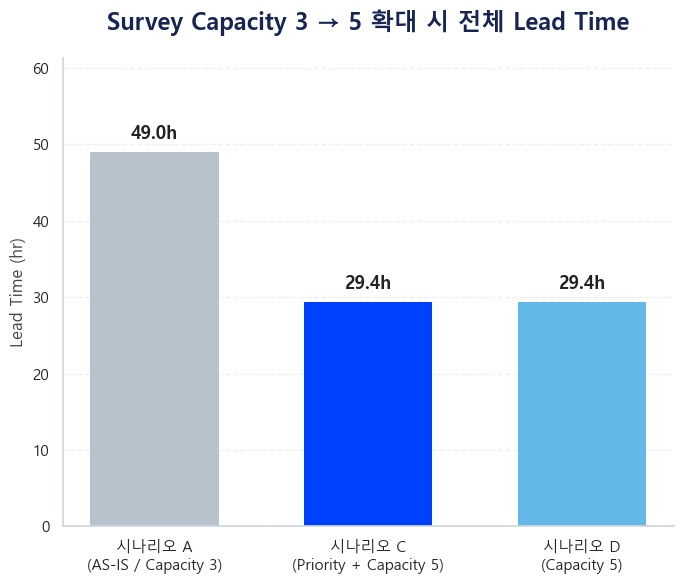

In [529]:
# 시나리오 B | VIP Lead Time 비교
# AS-IS vs Priority + Capacity 5 vs Capacity 5

scenario_order = ["시나리오 A (AS-IS)", "시나리오 C", "시나리오 D"]

plot_df = final_results[final_results["Scenario"].isin(scenario_order)].copy()

# 원하는 순서로 정렬
plot_df["Scenario"] = pd.Categorical(plot_df["Scenario"], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values("Scenario")

# 값
values = plot_df["Lead Time (hr)"].values


colors = [
    "#B8C2CC",   # AS-IS : 차분한 회색
    "#0040FF",   # 시도 2-C : 메인 블루
    "#62B8E8"    # 시도 2-D : 밝은 블루
]

# 그래프
fig, ax = plt.subplots(figsize=(7, 6))

x = np.array([0, 0.7, 1.4])

bars = ax.bar(x, values, width=0.42, color=colors, edgecolor="none")

# 막대 위 값 표시
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.2,
        f"{value:.1f}h",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#222222"
    )

# 약 40% 감소 표시
base_value = values[0]
scenario_c_value = values[1]

improvement = ((base_value - scenario_c_value) / base_value * 100)

#ax.annotate(
#    f"▼ {improvement:.1f}%",
#    xy=(1, scenario_c_value),
#    xytext=(1, 45),
#    arrowprops=dict(
#        arrowstyle="->",
#        color="#3155E7",
#        lw=2
#    ),
#    fontsize=14,
#    fontweight="bold",
#    color="#3155E7",
#    ha="center"
#)

ax.set_title(
    "Survey Capacity 3 → 5 확대 시 전체 Lead Time",
    fontsize=17,
    fontweight="bold",
    color="#172554",
    pad=20
)

ax.set_ylabel(
    "Lead Time (hr)",
    fontsize=12,
    color="#444444"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "시나리오 A\n(AS-IS / Capacity 3)",
        "시나리오 C\n(Priority + Capacity 5)",
        "시나리오 D\n(Capacity 5)"
    ],
    fontsize=11
)

ax.set_ylabel("Lead Time (hr)", fontsize=12)

# y축 범위
ax.set_ylim(0, max(values) * 1.25)

# 격자
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# 테두리
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D0D5DD")
ax.spines["bottom"].set_color("#D0D5DD")

plt.tight_layout()
plt.savefig("Survey Capacity 3 → 5 확대 시 전체 Lead Time", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

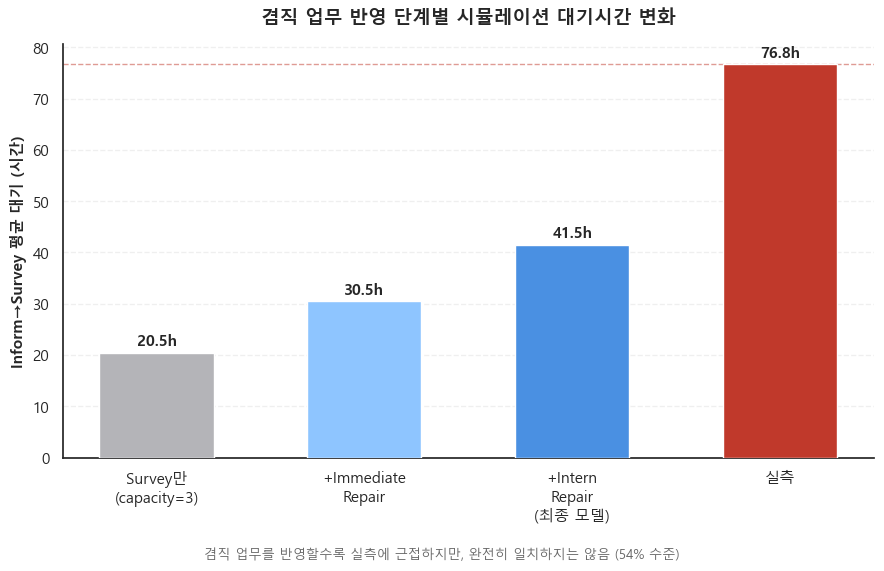

In [531]:
# 겸직 여부를 추가할수록 실측에 가까워지는 과정
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

stages = ["Survey만\n(capacity=3)", "+Immediate\nRepair", "+Intern\nRepair\n(최종 모델)", "실측"]
values = [20.48, 30.5, 41.52, 76.76]  # 중간값은 실제 노트북에서 확인한 값으로 교체
colors = ["#B4B4B8", "#8EC5FF", "#4A90E2", "#C0392B"]

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor="white")
bars = ax.bar(stages, values, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, values):
    ax.annotate(f"{val:.1f}h", xy=(bar.get_x()+bar.get_width()/2, val),
                xytext=(0,5), textcoords="offset points", ha="center",
                fontsize=11, fontweight="bold")

ax.axhline(76.76, color="#C0392B", linestyle="--", linewidth=1, alpha=0.5, zorder=1)
ax.set_title("겸직 업무 반영 단계별 시뮬레이션 대기시간 변화", fontsize=13.5, fontweight="bold", pad=15)
ax.set_ylabel("Inform→Survey 평균 대기 (시간)", fontsize=11, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.figtext(0.5, -0.03, "겸직 업무를 반영할수록 실측에 근접하지만, 완전히 일치하지는 않음 (54% 수준)",
            ha="center", fontsize=9.5, color="#666666", style="italic")

plt.tight_layout()
plt.savefig("attempt3_progression.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

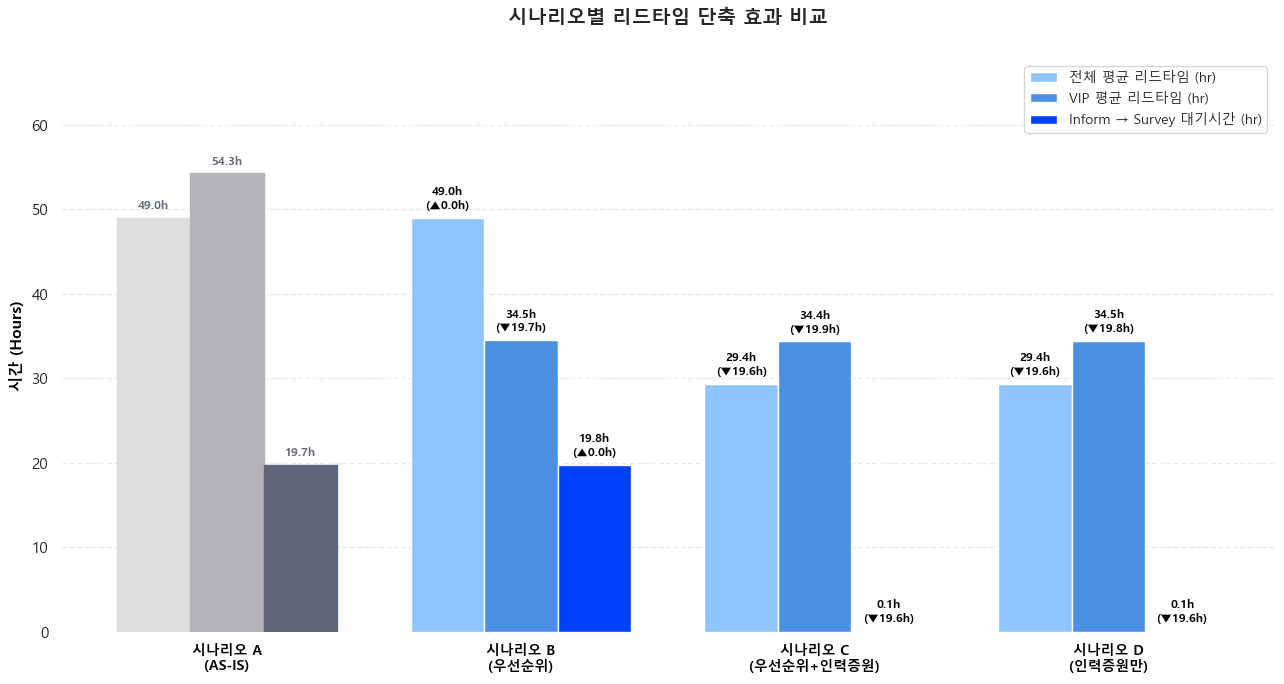


주의: C(29.4h)와 D(29.4h)의 차이가 미미합니다.


In [532]:
labels_all = [
    "시나리오 A\n(AS-IS)",
    "시나리오 B\n(우선순위)",
    "시나리오 C\n(우선순위+인력증원)",
    "시나리오 D\n(인력증원만)",
]

total_times = [scenario_A["lead_time_hr"], scenario_B["lead_time_hr"], scenario_C["lead_time_hr"], scenario_D["lead_time_hr"]]
vip_times = [scenario_A["vip_lead_time_hr"], scenario_B["vip_lead_time_hr"], scenario_C["vip_lead_time_hr"], scenario_D["vip_lead_time_hr"]]
bottleneck_times = [scenario_A["avg_queue_wait_hr"], scenario_B["avg_queue_wait_hr"], scenario_C["avg_queue_wait_hr"], scenario_D["avg_queue_wait_hr"]]

cap_sA = int(scenario_A["locked_capital_krw"] / 10000)
cap_sB = int(scenario_B["locked_capital_krw"] / 10000)
cap_sC = int(scenario_C["locked_capital_krw"] / 10000)
cap_sD = int(scenario_D["locked_capital_krw"] / 10000)
trapped_capital_all = [cap_sA, cap_sB, cap_sC, cap_sD]

def label_bars(rects, base_values):
    """AS-IS를 기준으로 각 시나리오의 변화량 표시"""
    for i, rect in enumerate(rects):
        height = rect.get_height()

        if i == 0:
            # AS-IS
            text = f"{height:.1f}h"
            font_color = "#61677A"
        else:
            # AS-IS 대비 변화량
            diff = base_values[0] - height

            if diff >= 0:
                text = f"{height:.1f}h\n(▼{diff:.1f}h)"
            else:
                text = f"{height:.1f}h\n(▲{abs(diff):.1f}h)"

            font_color = "#000000"

        ax.annotate(
            text,
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            color=font_color,
        )
        
x = np.arange(len(labels_all))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 7), facecolor="#ffffff")

COLOR_TOTAL = "#8EC5FF"
COLOR_VIP = "#4A90E2"
COLOR_BOTTLENECK = "#0040FF"

rects1 = ax.bar(x - width, total_times, width, label="전체 평균 리드타임 (hr)", color=COLOR_TOTAL, zorder=3)
rects2 = ax.bar(x, vip_times, width, label="VIP 평균 리드타임 (hr)", color=COLOR_VIP, zorder=3)
rects3 = ax.bar(x + width, bottleneck_times, width, label="Inform ➔ Survey 대기시간 (hr)", color=COLOR_BOTTLENECK, zorder=3)

# AS-IS는 대조군으로 회색 계열 유지
rects1[0].set_color("#DDDDDD")
rects2[0].set_color("#B4B4B8")
rects3[0].set_color("#61677A")

ax.set_title("시나리오별 리드타임 단축 효과 비교", fontsize=14, fontweight="bold", pad=25)
ax.set_ylabel("시간 (Hours)", fontsize=11, fontweight="bold", color="#000000")
ax.set_xticks(x)
ax.set_xticklabels(labels_all, fontsize=10, fontweight="bold", color="#000000")

legend_handles = [
    Patch(facecolor=COLOR_TOTAL, label="전체 평균 리드타임 (hr)"),
    Patch(facecolor=COLOR_VIP, label="VIP 평균 리드타임 (hr)"),
    Patch(facecolor=COLOR_BOTTLENECK, label="Inform → Survey 대기시간 (hr)"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, facecolor="#ffffff", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

label_bars(rects1, total_times)
label_bars(rects2, vip_times)
label_bars(rects3, bottleneck_times)

ax.set_ylim(0, max(vip_times) * 1.25)
plt.tight_layout()
plt.savefig("scenario_comparison_final.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n주의: C({scenario_C['lead_time_hr']:.1f}h)와 D({scenario_D['lead_time_hr']:.1f}h)의 차이가 미미합니다.")

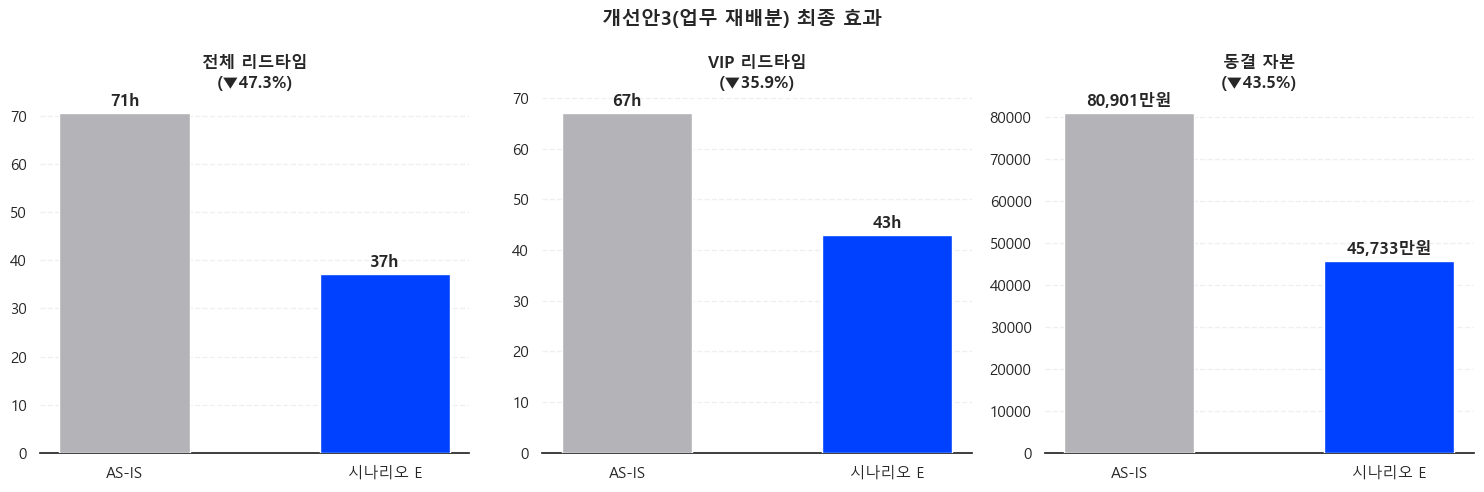

In [535]:
# 시나리오 C - 단독 상세 그래프(vip, 자본 포함)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="white")

metrics = [
    (
        "전체 리드타임",
        [as_is_integrated["lead_time_hr"].mean(), scenario_E_result["lead_time_hr"].mean()],
        "h"
    ),
    (
        "VIP 리드타임",
        [
            as_is_integrated.loc[as_is_integrated["vip_segment"]=="VIP", "lead_time_hr"].mean(),
            scenario_E_result.loc[scenario_E_result["vip_segment"]=="VIP", "lead_time_hr"].mean(),
        ],
        "h"
    ),
    (
        "동결 자본",
        [
            (as_is_integrated["repair_cost"] * (as_is_integrated["lead_time_hr"]/24)).sum() / 10000,
            (scenario_E_result["repair_cost"] * (scenario_E_result["lead_time_hr"]/24)).sum() / 10000,
        ],
        "만원"
    ),
]

for ax, (title, values, unit) in zip(axes, metrics):
    bars = ax.bar(["AS-IS", "시나리오 E"], values, color=["#B4B4B8", "#0040FF"], width=0.5, zorder=3)
    for bar, val in zip(bars, values):
        ax.annotate(f"{val:,.0f}{unit}", xy=(bar.get_x()+bar.get_width()/2, val),
                    xytext=(0,5), textcoords="offset points", ha="center", fontweight="bold")
    improve = (values[0]-values[1])/values[0]*100
    ax.set_title(f"{title}\n(▼{improve:.1f}%)", fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
    for spine in ["top","right","left"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("개선안3(업무 재배분) 최종 효과", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("scenario_e_detail.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## [추가] 재수리 부분 개선

In [536]:
# SOP 개선 : 재수리 프로세스를 표준화해서 불필요한 반복 진단, 재작업, 재접수를 줄이는 것이 목적
# 시나리오 A : 재수리 SOP - 재수리가 한 번이라도 발생한 케이스 (internReapir가 2회 이상 발생한 모든 케이스)
# 시나리오 B : 외주 모니터링 - Externrepair가 한 번이라도 발생한 케이스

In [537]:
# 내부 재수리 추가 리드타임 계산
base_internal = (
    repair_compare_df.loc[
        repair_compare_df["repair_sequence"] == "InternRepair",
        "actual_repair_time_minutes"
    ].mean()
)

redo_mask = (
    repair_compare_df["repair_sequence"].str.count("InternRepair") >= 2
) & (
    ~repair_compare_df["repair_sequence"].str.contains("ExternRepair", na=False)
)
redo_time = (
    repair_compare_df.loc[
        redo_mask,
        "actual_repair_time_minutes"
    ].mean()
)

REDO_DELAY_HR = (
    redo_time - base_internal
) / 60

print(f"내부 재수리 추가 리드타임 : {REDO_DELAY_HR:.2f}시간")

내부 재수리 추가 리드타임 : 31.72시간


In [538]:
# 외주 추가 리드타임 계산
external_mask = (
    repair_compare_df["repair_sequence"]
        .str.contains("ExternRepair", na=False)
)

external_time = (
    repair_compare_df.loc[
        external_mask,
        "actual_repair_time_minutes"
    ].mean()
)

EXTERN_DELAY_HR = (
    external_time - base_internal
) / 60

print(f"외주 추가 리드타임 : {EXTERN_DELAY_HR:.2f}시간")

외주 추가 리드타임 : 2.77시간


In [539]:
df_new = simulation_df.copy()

In [540]:
# 재수리 SOP
def scenario_redo(
    df,
    improve_rate=0.4
):

    sim = df.copy()
    
    redo_mask = (
        sim["repair_sequence"].str.count("InternRepair") >= 2
    ) & (
        ~sim["repair_sequence"].str.contains("ExternRepair", na=False)
    )
    
    sim.loc[
        redo_mask,
        "case_lead_time_hr"
    ] -= (
        REDO_DELAY_HR * improve_rate
    )
    
    sim["case_lead_time_hr"] = (
        sim["case_lead_time_hr"]
        .clip(lower=0)
    )
    return sim

In [541]:
def scenario_external(
    df,
    improve_rate=0.4
):

    sim = df.copy()

    external_mask = (
        sim["repair_sequence"]
            .str.contains("ExternRepair", na=False)
    )
    
    sim.loc[
        external_mask,
        "case_lead_time_hr"
    ] -= (
        EXTERN_DELAY_HR * improve_rate
    )
    
    sim["case_lead_time_hr"] = (
        sim["case_lead_time_hr"]
        .clip(lower=0)
    )

    return sim

In [542]:
# 재수리 + 외주 동시 개선
# Scenario C
# Internal Redo SOP + External Repair Monitoring
# Both improvements are applied simultaneously.
def scenario_dual(
    df,
    redo_improve=0.4,
    extern_improve=0.4
):

    sim = df.copy()

    redo_mask = (
        sim["repair_sequence"].str.count("InternRepair") >= 2
    ) & (
        ~sim["repair_sequence"].str.contains("ExternRepair", na=False)
    )
    
    external_mask = (
        sim["repair_sequence"]
            .str.contains("ExternRepair", na=False)
    )
    
    sim.loc[
        redo_mask,
        "case_lead_time_hr"
    ] -= (
        REDO_DELAY_HR * redo_improve
    )
    
    sim.loc[
        external_mask,
        "case_lead_time_hr"
    ] -= (
        EXTERN_DELAY_HR * extern_improve
    )

    sim["case_lead_time_hr"] = (
        sim["case_lead_time_hr"]
        .clip(lower=0)
    )

    return sim

In [543]:
def calc_locked_capital_new(df):

    return (
        df["repair_cost"]
        *
        (df["case_lead_time_hr"] / 24)
    ).sum()


def get_metrics_new(df):

    SLA_LIMIT = 166.7

    success_rate = (
        df["case_lead_time_hr"]
        <= SLA_LIMIT
    ).mean() * 100

    fail_rate = 100 - success_rate

    fail_count = (
        df["case_lead_time_hr"]
        > SLA_LIMIT
    ).sum()

    return {

        "lead_time":
        df["case_lead_time_hr"].mean(),

        "sla_success":
        success_rate,

        "sla_fail":
        fail_rate,

        "sla_fail_count":
        fail_count,

        "capital":
        calc_locked_capital_new(df)
    }

In [544]:
asis_new = get_metrics_new(df_new)

redo_new = get_metrics_new(
    scenario_redo(df_new)
)

extern_new = get_metrics_new(
    scenario_external(df_new)
)

dual_new = get_metrics_new(
    scenario_dual(df_new)
)

In [545]:
def print_result(
    name,
    result,
    base
):

    benefit = (
        base["capital"]
        -
        result["capital"]
    )

    print()
    print("="*65)
    print(name)
    print("="*65)

    print(
        f"▶ 평균 리드타임 : "
        f"{base['lead_time']:.2f}h → "
        f"{result['lead_time']:.2f}h "
        f"(▼ {base['lead_time']-result['lead_time']:.2f}h)"
    )

    print(
        f"▶ SLA 성공률 : "
        f"{base['sla_success']:.1f}% → "
        f"{result['sla_success']:.1f}% "
        f"({result['sla_success']-base['sla_success']:+.1f}%p)"
    )

    print(
        f"▶ SLA 실패율 : "
        f"{base['sla_fail']:.1f}% → "
        f"{result['sla_fail']:.1f}% "
        f"(▼ {base['sla_fail']-result['sla_fail']:.1f}%p)"
    )

    print(
        f"▶ SLA 실패 건수 : "
        f"{base['sla_fail_count']}건 → "
        f"{result['sla_fail_count']}건 "
        f"(▼ {base['sla_fail_count']-result['sla_fail_count']}건)"
    )

    print(
        f"▶ 자본 조기 회수 : "
        f"{benefit/10000:,.0f}만 원"
    )

In [546]:
print_result(
    "Scenario A | 재수리 SOP",
    redo_new,
    asis_new
)

print_result(
    "Scenario B | 외주 모니터링",
    extern_new,
    asis_new
)

print_result(
    "Scenario C | 재수리 + 외주 개선",
    dual_new,
    asis_new
)


Scenario A | 재수리 SOP
▶ 평균 리드타임 : 105.87h → 105.37h (▼ 0.50h)
▶ SLA 성공률 : 74.1% → 74.1% (+0.0%p)
▶ SLA 실패율 : 25.9% → 25.9% (▼ 0.0%p)
▶ SLA 실패 건수 : 240건 → 240건 (▼ 0건)
▶ 자본 조기 회수 : 699만 원

Scenario B | 외주 모니터링
▶ 평균 리드타임 : 105.87h → 105.71h (▼ 0.16h)
▶ SLA 성공률 : 74.1% → 74.2% (+0.1%p)
▶ SLA 실패율 : 25.9% → 25.8% (▼ 0.1%p)
▶ SLA 실패 건수 : 240건 → 239건 (▼ 1건)
▶ 자본 조기 회수 : 288만 원

Scenario C | 재수리 + 외주 개선
▶ 평균 리드타임 : 105.87h → 105.21h (▼ 0.66h)
▶ SLA 성공률 : 74.1% → 74.2% (+0.1%p)
▶ SLA 실패율 : 25.9% → 25.8% (▼ 0.1%p)
▶ SLA 실패 건수 : 240건 → 239건 (▼ 1건)
▶ 자본 조기 회수 : 987만 원


In [547]:
simulation_df.groupby("repair_sequence").agg(
    sla_fail_rate=("sla_status", lambda x: (x == "Fail").mean() * 100)
)

,sla_fail_rate
repair_sequence,
ExternRepair,15.254237
ImmediateRepair,17.701863
ImmediateRepair > ExternRepair,5.263158
ImmediateRepair > InternRepair,0.000000
ImmediateRepair > InternRepair > ExternRepair,0.000000
ImmediateRepair > InternRepair > InternRepair,0.000000
InternRepair,35.083532
InternRepair > ExternRepair,27.586207
InternRepair > InternRepair,48.571429


In [548]:
redo_mask = (
    simulation_df["repair_sequence"]
    .str.count("InternRepair") >= 2
)

external_mask = (
    simulation_df["repair_sequence"]
    .str.contains("ExternRepair", na=False)
)

print(
    (simulation_df.loc[redo_mask, "sla_status"] == "Fail").mean() * 100
)

print(
    (simulation_df.loc[external_mask, "sla_status"] == "Fail").mean() * 100
)

44.73684210526316
14.393939393939394
